In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [3]:
if_renormalon = False

In [204]:
results_df = pd.read_csv("result/fit_N3LL'.csv")

Import

In [205]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    corrected_string = corrected_string.replace(",,", ",")
    return ast.literal_eval(corrected_string)

αs_array = results_df['αs'].to_numpy()
params = results_df['params'].apply(convert_to_list)
params = np.array(params.to_list())

rows = len(params)
cols = len(params[0])
a_list = {}

if if_renormalon == False:
    for i in range(cols):
        a_list[i] = params[:,i]
if if_renormalon == True:
    Ω1_array = params[:,0]
    for i in range(cols-1):
        a_list[i] = params[:,i+1]

In [206]:
print("αs_error:",(max(αs_array)-min(αs_array))/2) 

αs_error: 0.0009837288050248486


Correlation

In [207]:
data = {
    'αs': αs_array,
    'a1': a_list[0],
    'a2': a_list[1]
}
df = pd.DataFrame(data)
X = df.values

cov_matrix = np.cov(X, rowvar=False)
std_devs = np.sqrt(np.diag(cov_matrix))
corr_matrix = cov_matrix / np.outer(std_devs, std_devs)

mean = np.array([np.mean(data["αs"]),np.mean(data['a1']),np.mean(data['a2'])])

display("mean:", mean)
display("covariance matrix:", corr_matrix)

'mean:'

array([ 0.11648382, -0.09620906,  0.56561051])

'covariance matrix:'

array([[ 1.        , -0.04512326, -0.43937165],
       [-0.04512326,  1.        , -0.02548878],
       [-0.43937165, -0.02548878,  1.        ]])

Plot

In [195]:
scale_68 = np.sqrt(2.279)
scale_95 = np.sqrt(5.991)

from matplotlib.patches import Ellipse
def draw_ellipse(mean, cov, scale, ax, **kwargs):

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = 2.0 * scale * np.sqrt(eigenvalues)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    ell = Ellipse(xy=mean, width=eigenvalues[0], height=eigenvalues[1], angle=angle, **kwargs)
    
    ax.add_artist(ell)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

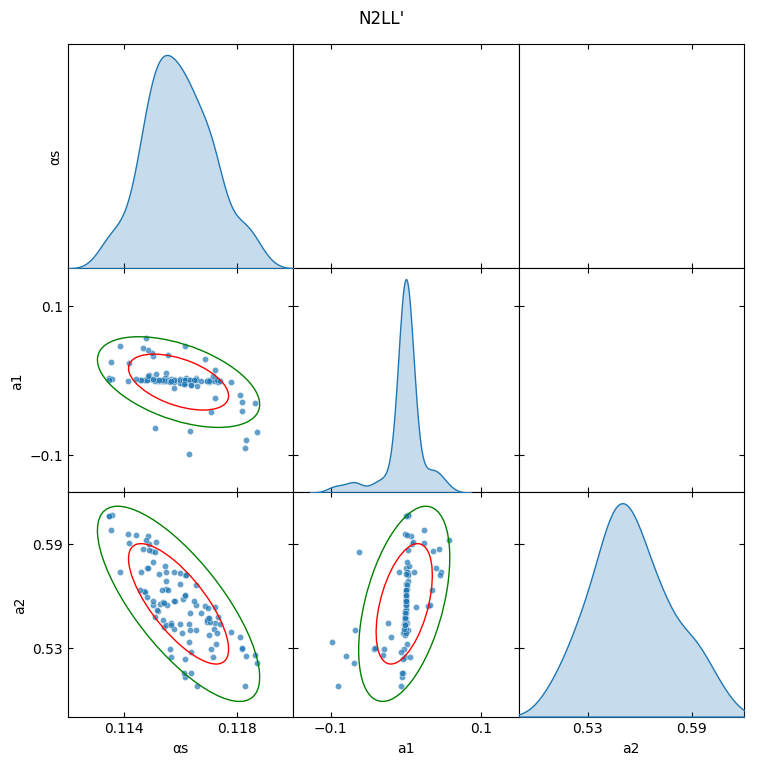

In [203]:
import seaborn as sns
import matplotlib as mpl

g = sns.PairGrid(df, diag_sharey=False)
g.map_lower(sns.scatterplot, s=20, alpha=0.7)
g.map_diag(sns.kdeplot, shade=True)

for i, j in zip(*np.tril_indices_from(g.axes, -1)):
    ax = g.axes[i, j]
    mean = df[['αs', 'a1', 'a2']].mean().values[[j, i]]
    cov = np.cov(df[['αs', 'a1', 'a2']].values.T[[j, i]])
    draw_ellipse(mean, cov, scale_68, ax, edgecolor='r', fc='None')
    draw_ellipse(mean, cov, scale_95, ax, edgecolor='g', fc='None')

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(direction='in', top=True, right=True)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

g.axes[0, 0].set_xlim(0.112,0.12)
g.axes[0, 0].set_xticks([0.114,0.118])
g.axes[0, 1].set_xlim(-0.15,0.15)
g.axes[0, 1].set_xticks([-0.1,0.1])
g.axes[0, 2].set_xlim(0.49,0.62)
g.axes[0, 2].set_xticks([0.53,0.59])

g.axes[2, 0].set_ylim(0.49,0.62)
g.axes[2,0].set_yticks([0.53,0.59])
g.axes[1, 0].set_ylim(-0.15,0.15)
g.axes[1, 0].set_yticks([-0.1,0.1])

g.axes[0, 0].set_yticks([])

plt.subplots_adjust(wspace=0.0, hspace=0.0)
g.add_legend()
plt.suptitle("N2LL'", y=1.02)
plt.show()